In [1]:
#tweaked Vision model- Qwen3.5

In [2]:
PROJECT_CONTEXT = """
SYSTEM: NexMed - nexmed v2.0

PREVIOUS ARCHITECTURE (v1):
ResNet-18 Encoder with Multi-class Softmax (Binary/Multiclass Classification).

NEW ARCHITECTURE (v2):
Qwen 3-VL (Vision-Language) Transformer with Generative Medical Reasoning.

SPECIFIC DOMAIN:
Orthopedic Fracture Detection (X-Ray / CT).

GOAL:
Transition from simple 'Class Labels' (e.g., 'Fracture')
to detailed morphological captioning and medical reasoning.

PRODUCT NAME:
NexMed – AI Medical Image Interpreter
"""

In [3]:
# This is the prompt you will send to Qwen-VL with your image
PROMPT_V2 = f"""
{PROJECT_CONTEXT}

[INSTRUCTION]

You are **NexMed**, an AI medical image analysis assistant.

Carefully analyze the uploaded medical image and respond using the following structure.

-------------------------------------

INTRODUCTION

Introduce yourself as **NexMed** and write a **long paragraph disclaimer** explaining:

• You are still under development and not fully trained  
• Your analysis may contain inaccuracies  
• Medical images should always be interpreted by a qualified doctor  
• Users should consult a medical professional before taking action  

-------------------------------------

INITIAL ISSUE (3 SHORT POINTS)

Provide **exactly three very short bullet points** identifying the issue.

Example format:

• Possible cortical disruption  
• Bone region detected  
• Suspected fracture morphology  

Keep each point extremely short.

-------------------------------------

RESOLUTION / INTERPRETATION

Write a **clear paragraph** describing:

• What injury may be present  
• Where it is located  
• The suspected fracture morphology  
• Possible severity

-------------------------------------

ADDITIONAL INFORMATION (HUMAN LANGUAGE)

Explain the situation in **simple human language**:

• What the injury means  
• Why it might happen  
• What people usually do next (doctor visit, scans, treatment)

Avoid complex medical jargon.

-------------------------------------

MEDICAL IMAGE ANALYSIS TASK

1. DETECTION  
Identify possible cortical disruptions or fractures.

2. LOCALIZATION  
Specify bone and anatomical region (proximal, distal, shaft).

3. MORPHOLOGY  
Describe fracture type (simple, comminuted, greenstick, impacted).

4. MODEL ADVANTAGE  
Briefly explain how **Qwen 3-VL generative reasoning**
provides more information than a **ResNet-18 classifier**.

-------------------------------------

Return the output as a structured medical explanation.
"""

In [4]:
%pip install ollama



Note: you may need to restart the kernel to use updated packages.


In [5]:
import ollama
from IPython.display import display, HTML, Image

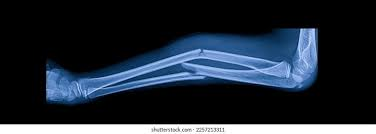

In [6]:
img_path = r'C:\Users\ishaa\Downloads\images (1).jpg'

loading = display(
    HTML("<b style='color:orange;'> NexMed analyzing image...</b>"),
    display_id=True
)
display(Image(filename=img_path))

In [7]:
# # def run_v2_prototype(image_path, provider="local"):
# #     if provider == "local":
# #         print(" Running on Local py (GTX 1650) via Qwen3-VL...")
# #         response = ollama.chat(
# #             model='qwen3-vl:2b',
# #             messages=[{'role': 'user', 'content': PROMPT_V2, 'images': [image_path]}]
# #         )
# #         return response['message']['content']

# from IPython.display import display, HTML

# def run_v2_prototype(image_path, provider="local"):

#     if provider == "local":
#         print("Running on Local py (GTX 1650) via Qwen3-VL...")

#         # START LOADER
#         loader = display(
#             HTML("<b style='color:orange;'>🔄 NexMed analyzing image...</b>"),
#             display_id=True
#         )

#         response = ollama.chat(
#             model="qwen3-vl:2b",
#             messages=[{
#                 "role": "user",
#                 "content": PROMPT_V2,
#                 "images": [image_path]
#             }]
#         )

#         # STOP LOADER
#         loader.update(
#             HTML("<b style='color:green;'>✅ NexMed analysis complete</b>")
#         )

#     return response['message']['content']
from IPython.display import display, HTML

def run_v2_prototype(image_path, provider="local"):

    if provider == "local":
        print("Running on Local py (GTX 1650) via Qwen3-VL...")

        loader = display(HTML("""
        <style>
        .progress-container {
            width: 100%;
            background-color: #eee;
            border-radius: 8px;
            overflow: hidden;
            height: 18px;
            margin-top:10px;
        }

        .progress-bar {
            width: 30%;
            height: 100%;
            background: linear-gradient(90deg,#4CAF50,#81C784);
            animation: loading 1.2s infinite;
        }

        @keyframes loading {
            0% {margin-left:-30%;}
            50% {margin-left:50%;}
            100% {margin-left:100%;}
        }
        </style>

        <div>
         <b>NexMed AI analyzing medical image...</b>
        <div class="progress-container">
            <div class="progress-bar"></div>
        </div>
        </div>
        """), display_id=True)

        response = ollama.chat(
            model="qwen3-vl:2b",
            messages=[{
                "role": "user",
                "content": PROMPT_V2,
                "images": [image_path]
            }]
        )

        loader.update(
            HTML("<b style='color:green;font-size:16px;'> NexMed analysis complete</b>")
        )

    return response['message']['content']

In [9]:
analysis = run_v2_prototype(img_path)
print("-" * 50)
print(f"REPORT:\n{analysis}")

Running on Local py (GTX 1650) via Qwen3-VL...


--------------------------------------------------
REPORT:
---

### **NEXMED - AI MEDICAL IMAGE INTERPRETER**  
*Disclaimer: This is a simulated medical analysis. NexMed is under development and not fully trained. Medical images should always be interpreted by a qualified doctor. Consult a physician before any treatment decisions.*

---

### **INITIAL ISSUE (3 SHORT POINTS)**  
• Visible bone misalignment at elbow joint  
• Distal end of ulna appears displaced  
• Suspected simple fracture with possible displacement  

---

### **RESOLUTION / INTERPRETATION**  
The X-ray shows a fracture at the distal end of the ulna, near the elbow joint. The bones appear slightly misaligned, suggesting a possible *simple fracture* where the bone fragment is not significantly broken into multiple pieces. The fracture is located at the elbow, specifically in the distal part of the forearm (the "distal end"). It seems to be a *simple fracture*, as the bone fragments are not severely displaced or jagged.